In [20]:
import pandas as pd
import os
print(os.getcwd())

C:\Users\acer


In [21]:
print(os.listdir())

[' abhay0001', ' app.py', ' churn_analysis.ipynb', '.anaconda', '.antigravity', '.conda', '.condarc', '.continuum', '.gemini', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kivy', '.matplotlib', '.redhat', '.streamlit', '.virtual_documents', '.vscode', '.vscode-shared', '.~ churn_analysis.ipynb', 'anaconda3', 'anaconda_projects', 'app.py', 'AppData', 'Application Data', 'c tutorial', 'cd', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'European_Bank.csv', 'Favorites', 'grocery.db', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{4349d1eb-a6a0-11ef-b15c-86fee2a1d7ff}.TM.blf', 'NTUSER.DAT{4349d1eb-a6a0-11ef-b15c-86fee2a1d7ff}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{4349d1eb-a6a0-11ef-b15c-86fee2a1d7ff}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'rajesh-portfolio', 'Recent', 'Searches', 'SendTo', 'Start Menu',

In [19]:
df=pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\customer_churn_project\European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape
 

(10000, 14)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
# df.drop(['Surname'],axis=1,inplace=True)

In [8]:
df.columns.tolist()

['Year',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [26]:
# overall churn rate
overall_churn=df['Exited'].mean()*100
print("Overall Churn Rate=",round(overall_churn,2),"%")

Overall Churn Rate= 20.37 %


In [32]:
#1 Geography wise churn
geo_churn=df.groupby('Geography')['Exited'].mean()*100
print(round(geo_churn,2),"%")

Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64 %


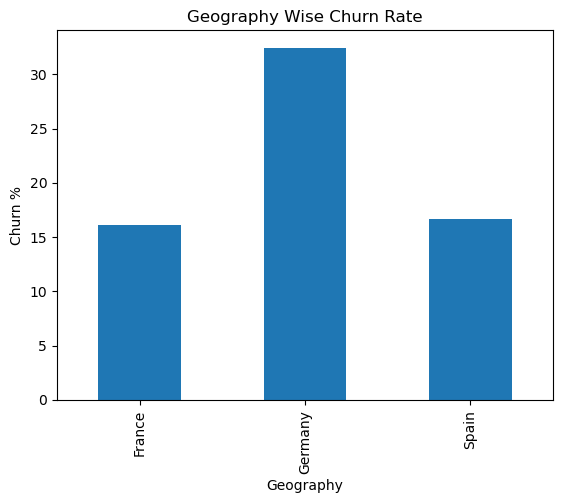

In [11]:
# 2Graph
import matplotlib.pyplot as plt
geo_churn.plot(kind='bar')
plt.title("Geography Wise Churn Rate")
plt.ylabel("Churn %")
plt.show()

In [12]:
#3 Gender wise churn
gender_churn=df.groupby("Gender")["Exited"].mean()*100
print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


In [13]:
#4 age  segmentation
df["Age_Group"]=pd.cut(
    df['Age'],
    bins=[0,30,45,60,100],
    labels=['<30','30-45','46-60','60+']
)
age_churn=df.groupby("Age_Group")['Exited'].mean()*100
print(age_churn)

Age_Group
<30       7.520325
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_19712\4044428518.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn=df.groupby("Age_Group")['Exited'].mean()*100


In [14]:
#5 CREADIT SCORE BANDS
df['Credit_Band']=pd.cut(
    df['CreditScore'],
    bins=[0,500,700,1000],
    labels=['Low','Medium','High']
)
credit_churn=df.groupby('Credit_Band')['Exited'].mean()*100
print(credit_churn)

Credit_Band
Low       23.639191
Medium    20.285211
High      19.865212
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_19712\2352579585.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_churn=df.groupby('Credit_Band')['Exited'].mean()*100


In [15]:
#6 high value customer  churn
high_value=df[df["Balance"]>100000]
high_value_churn=high_value["Exited"].mean()*100
print("High Value Customer Churn=",
      round(high_value_churn,2), "%")

High Value Customer Churn= 25.23 %


In [16]:
# Active member analysis
active_churn=df.groupby("IsActiveMember")["Exited"].mean()*100
print(active_churn)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [17]:
print(os.listdir())

[' abhay0001', ' app.py', ' churn_analysis.ipynb', '.anaconda', '.antigravity', '.conda', '.condarc', '.continuum', '.gemini', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kivy', '.matplotlib', '.redhat', '.streamlit', '.virtual_documents', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'app.py', 'AppData', 'Application Data', 'c tutorial', 'cd', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'European_Bank.csv', 'Favorites', 'grocery.db', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{4349d1eb-a6a0-11ef-b15c-86fee2a1d7ff}.TM.blf', 'NTUSER.DAT{4349d1eb-a6a0-11ef-b15c-86fee2a1d7ff}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{4349d1eb-a6a0-11ef-b15c-86fee2a1d7ff}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'rajesh-portfolio', 'Recent', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Videos']
